# 03 - Classical and probabilistic models

Two complementary classical-ML model families, evaluated the same way as
the baselines in notebook 02:

- **Part A -- external-predictor tabular models**: regression/tree models
  trained on engineered daily feature rows (calendar, satellite,
  meteorological, oceanographic), with no access to the target's own
  history. Safe for any gap length.
- **Part B -- gap-edge residual and probabilistic sequence models**:
  models that predict a correction over linear interpolation using
  information from both edges of a gap, plus the Gaussian process and
  Kalman components behind the released "engineered hybrid" pipeline.
  Retrospective by construction, not forecast-safe.

Both parts run real, small samples of the published drivers directly (not
a re-description of them) and load the full released comparison tables for
the validation-grade numbers.

## Part A.1 What is an external-predictor tabular model?

A tabular model treats each calendar day as one row of a feature table and
predicts a single target value (here, daily mean chlorophyll-a) from the
other columns in that row -- the same setup as any standard regression or
classification problem. The "external-predictor" qualifier means the
feature columns are restricted to information that does not depend on the
target series' own recent observed values: calendar position, satellite
sea-surface temperature, a satellite chlorophyll proxy, wind, and
upwelling-related variables from a nearby meteorological station and
reanalysis products.

This is deliberately different from a *gap-edge* model (Part B below),
which is allowed to look at the target's own value immediately before and
after a gap. External-predictor models are safe to use on **any** gap,
including very long ones or gaps near the edge of the record, because they
never require a recent target observation to exist.

## Part A.2 Why temporal awareness must be engineered by hand

A single row of a tabular model has no built-in concept of "yesterday" or
"a rolling average of the last week" -- each row is treated independently
by most regression/tree algorithms. If the underlying process has memory
(today's chlorophyll is correlated with yesterday's wind, or with a
multi-day upwelling trend), that memory has to be exposed explicitly as
extra columns:

- **Lags** -- the value of a predictor N days earlier (e.g.
  `wind_u_ms_lag3`, `mur_sst_degC` shifted by a fixed offset).
- **Rolling summaries** -- a moving average or sum over a trailing window
  (e.g. `plv_solar_roll7d_wm2`, `cmems_upwelling_cumul14d_ms_d`).
- **Anomalies** -- a predictor's deviation from its typical seasonal value
  (e.g. `mur_sst_anom_doy_degC`, `chl_anom_log10_monthly`), which separates
  an unusually warm/cool day from the normal seasonal cycle.
- **Availability flags** -- a boolean column (e.g. `wind_available`,
  `chl_cons_available`) recording whether the underlying source actually
  had data that day, since satellite products have their own gaps
  (cloud cover, swath coverage) independent of the in-situ sensor's gaps.

Each lag/rolling/anomaly variant is a design decision, not something a
plain tabular model infers automatically. The curated feature table in
this repository already has many of these variants pre-computed; building
an equivalent table from scratch for a new sensor or site requires
re-doing this work (see `docs/methods.md` and
`notebooks/06_oxygen_case_study.ipynb`).

## Part A.3 Loading the curated external-predictor feature table

`chlorophyll_predictor_features_curated.csv` has one row per calendar day
(3,988 rows) and 126 columns. Column families include:

- calendar: `season`, `day_of_year`, `month`, `year`, `doy_sin`, `doy_cos`
- satellite chlorophyll proxy: `chl_cons_log10`, `chl_perm_log10`, and
  their lag/roll/anomaly/patchiness variants
- sea-surface temperature: `mur_sst_degC`, `ostia_sst_degC`,
  `sst_primary_degC`, and SST gradient/frontal features
- wind: `wind_u_ms`, `wind_v_ms`, `wind_spd_ms` (CMEMS reanalysis) and
  `plv_wind_*` (nearby meteorological station)
- meteorological forcing: `plv_temp_degC`, `plv_pressure_hPa`,
  `plv_humid_pct`, `plv_precip_daily_mm`, `plv_solar_wm2`
- upwelling indices: `plv_upwelling_ms`, `cmems_upwelling_ms`, and their
  cumulative/relaxation-index variants

See `docs/data_dictionary.md` for the full column-by-column listing.

In [1]:
import pandas as pd

features = pd.read_csv(
    "../data/chlorophyll/chlorophyll_predictor_features_curated.csv",
    parse_dates=["date"],
)
print(features.shape)
features[[
    "date", "season", "chl_cons_log10", "mur_sst_degC",
    "wind_spd_ms", "plv_upwelling_ms",
]].head()

(3988, 126)


,date,season,chl_cons_log10,mur_sst_degC,wind_spd_ms,plv_upwelling_ms
0,2015-07-01,JJA,0.408127,13.270990,2.503007,-2.335232
1,2015-07-02,JJA,0.114188,13.269983,3.072794,-3.103372
2,2015-07-03,JJA,0.893770,13.260980,3.931441,-2.730098
3,2015-07-04,JJA,0.001893,13.451990,1.969993,-0.082689
4,2015-07-05,JJA,NaN,13.463983,2.624734,-1.892782


## Part A.4 Why external predictors alone did not clearly beat interpolation

In this benchmark's artificial-gap validation, external-predictor tabular
models (trained only on the feature families above, with no access to the
target's own recent history) did **not** show a clear, statistically
significant improvement over linear interpolation across most gap
lengths. Two probabilistic sequence models (Part B below) and TS-ICL
(notebook 04) performed competitively or better. The validated comparison
numbers are in `results/chlorophyll/chlorophyll_benchmark_summary.csv` and
`results/chlorophyll/chlorophyll_artificial_gap_scores.csv`.

Plausible reasons, in this local, relatively low-data setting (roughly a
decade of daily data at a single station):

- the record is short enough that a tabular model has limited examples to
  learn from, especially for less common conditions (long gaps, event
  days);
- external predictors capture broad physical forcing (temperature, wind,
  upwelling) but do not directly observe the target variable's own
  short-term persistence, which linear interpolation exploits by
  construction over short gaps;
- chlorophyll-a at this site is noisy and event-driven (see
  `docs/evidence_and_limitations.md`), and external predictors alone do
  not fully explain that variability.

More feature engineering and a more complex model family are not
guaranteed to beat a much simpler baseline; that comparison should always
be checked against validation-grade evidence rather than assumed.

## Part A.5 Two external-tabular protocols, kept deliberately separate

This project evaluated external-predictor tabular models under
**two distinct protocols**, kept as two separate, separately-named
methods rather than conflated:

- **Plain external-only protocol** (`experiments/chlorophyll/tabular_models.py`,
  method IDs `external_only_extratrees`/`external_only_hgb`): the 47-column
  `arm4` feature set only (46 numeric after `sst_primary_source` is dropped
  at fit time -- `tabular_models.ARM4_COLUMNS`), no information about the
  gap's length or the hidden day's position within it. Evaluated for its
  own sake -- it is **not** the protocol that produced the released
  `chlorophyll_matched_support_method_metrics.csv` numbers.
- **Matched-reference protocol** (`experiments/chlorophyll/gap_edge_models.py`'s
  `run_reference_arm_loco_evaluation`, method IDs `ext_tabular_extratrees`/
  `ext_tabular_hgb`): the same 46 `arm4` columns **plus 5 structural
  meta-features** describing gap length and within-gap position
  (`gap_length`, `day_index_within_gap`, `gap_position_fraction`,
  `distance_to_left_edge`, `distance_to_right_edge` -- never a hidden
  target value), fit under leave-one-gap-out with a stricter dependency-
  window exclusion. **This is the protocol that actually produced the
  released `ext_tabular_extratrees`/`ext_tabular_hgb` rows.** Because it
  conditions on gap length/position, this protocol is not strictly
  external-only or forecast-safe in the same sense as the plain protocol:
  it assumes the gap's length and the hidden day's position are known in
  advance, even though it never reads a hidden target value.

`ExtraTreesRegressor(n_estimators=500)` is the canonical learner in both
protocols; `HistGradientBoostingRegressor` is retained in both as a
diagnostic comparator only.

The cells below run both protocols, leave-one-gap-out, on a small sample of
gaps (not the full 449-gap matched support -- that takes several minutes
and belongs in a background run). To reproduce the full released
comparison, see `docs/reproducibility.md`.

In [2]:
import sys

import numpy as np

sys.path.insert(0, "..")

from experiments.chlorophyll import benchmark_contract as bc
from experiments.chlorophyll import gap_edge_models as gem
from experiments.chlorophyll import tabular_models as tm

target = pd.read_csv(
    "../data/chlorophyll/chlorophyll_daily_target.csv", parse_dates=["date"]
).set_index("date").sort_index()

arm4_cols = tm.load_arm4_numeric_columns(features.set_index("date"))
print(f"arm4: {len(arm4_cols)} numeric columns (of {len(tm.ARM4_COLUMNS)} published)")
print(f"forbidden target-history columns present: {tm.forbidden_target_history_columns(arm4_cols)}")

# A small, real sample from the released matched-support pool (see
# benchmark_contract.py) -- not the full 449 gaps, for notebook runtime.
sample = bc.load_matched_support_pool().sample(n=8, random_state=0)

# Plain external-only protocol (arm4 only, no gap-position features).
preds_ext_only_et, _ = tm.run_loco_evaluation(
    "external_only_extratrees", sample, target, features.set_index("date"), arm4_cols
)
preds_ext_only_hgb, _ = tm.run_loco_evaluation(
    "external_only_hgb", sample, target, features.set_index("date"), arm4_cols
)

# Matched-reference protocol (arm4 + 5 gap-position meta-features) -- this is
# the protocol that produced the released ext_tabular_extratrees/hgb rows.
preds_matched_et, _ = gem.run_reference_arm_loco_evaluation(
    "extratrees", sample, target, features.set_index("date"), arm4_cols
)
preds_matched_hgb, _ = gem.run_reference_arm_loco_evaluation(
    "hgb", sample, target, features.set_index("date"), arm4_cols
)

for name, preds in [
    ("Plain external-only, ExtraTrees", preds_ext_only_et),
    ("Plain external-only, HGB (diagnostic)", preds_ext_only_hgb),
    ("Matched-reference (released protocol), ExtraTrees", preds_matched_et),
    ("Matched-reference (released protocol), HGB (diagnostic)", preds_matched_hgb),
]:
    err = (preds["pred_log10"] - np.log10(preds["true"].clip(lower=1e-4))).abs()
    print(f"{name}: {len(preds)} predicted days, day-weighted MAE (log10) = {err.mean():.4f}")

print(
    "\nThis 8-gap sample's MAE is illustrative only -- it will not match the "
    "released 449-gap matched-support MAE in "
    "results/chlorophyll/chlorophyll_matched_support_method_metrics.csv "
    "(different, much smaller support, and the plain external-only protocol has "
    "no released row to compare against in the first place)."
)

arm4: 46 numeric columns (of 47 published)
forbidden target-history columns present: []


Plain external-only, ExtraTrees: 57 predicted days, day-weighted MAE (log10) = 0.1698
Plain external-only, HGB (diagnostic): 57 predicted days, day-weighted MAE (log10) = 0.1768
Matched-reference (released protocol), ExtraTrees: 57 predicted days, day-weighted MAE (log10) = 0.2092
Matched-reference (released protocol), HGB (diagnostic): 57 predicted days, day-weighted MAE (log10) = 0.2176

This 8-gap sample's MAE is illustrative only -- it will not match the released 449-gap matched-support MAE in results/chlorophyll/chlorophyll_matched_support_method_metrics.csv (different, much smaller support, and the plain external-only protocol has no released row to compare against in the first place).


## Part A.6 Takeaways

- External-predictor tabular models are useful because they generalize to
  any gap length and any position in the record, with no dependence on
  recent target observations.
- Building a good feature table requires designing lags, rolling windows,
  anomalies, and availability flags one at a time, ideally tracked in a
  feature registry with an explicit ablation plan rather than added all at
  once.
- In this project's low-data, single-station setting, external predictors
  alone did not clearly outperform linear interpolation under
  validation-grade testing.
- Part B below covers a complementary model family that additionally uses
  gap-edge information; notebook 04 covers the leading method in this
  benchmark under artificial-gap validation.

---

## Part B.1 What is a gap-edge residual correction model?

Linear interpolation between the last observation before a gap and the
first observation after it is already a strong baseline for short, smooth
gaps (notebook 02). A gap-edge residual correction model starts from that
same linear interpolation and learns to predict the **residual** -- how
far the true (withheld) value is likely to deviate from the straight-line
interpolation -- using extra information available at both edges of the
gap and from the engineered external predictors of Part A.

This is a different strategy from training a model to predict the target
value directly: by construction, the model only has to learn the
*correction*, which can be a smaller, easier-to-learn signal than the raw
target value, especially when interpolation is already a reasonable
starting point.

## Part B.2 Why this approach is retrospective, not forecast-safe

A gap-edge residual model needs an observation **after** the gap (the
"post-edge" value) to compute the interpolation baseline it corrects, and
to construct several of its own input features (e.g. a post-gap rolling
summary). That means it can only be used:

- to fill an **artificial gap** in a validation experiment, where the
  surrounding real data exists and was only masked for testing, or
- to retrospectively reconstruct a **real gap** after the sensor came
  back online and post-gap data became available.

It **cannot** be used for live forecasting (predicting today's value
without knowing tomorrow's), because the post-edge information it depends
on does not exist yet in a forecasting setting. This mirrors the same
caveat already noted for plain linear interpolation (`docs/methods.md`),
and is why this project's scope is diagnostic reconstruction, not
forecasting.

## Part B.3 How the correction is predicted

At a high level:

1. Compute the linear interpolation baseline for the gap (using the
   pre-edge and post-edge observed values).
2. Compute a set of gap-edge and engineered-predictor features for the
   gap (Part B.4 below).
3. Train a regression model (e.g. ridge regression, random forest,
   gradient boosting) to predict `true_value - interpolation_baseline`
   (the residual) from those features, using gaps where the true value is
   known (i.e. artificial gaps in the validation pool).
4. At prediction time, for a new gap, compute the interpolation baseline
   and the same features, predict the residual, and add it back:
   `prediction = interpolation_baseline + predicted_residual`.

This keeps the model's job bounded: even if the residual prediction is
poor, the result degrades gracefully toward the interpolation baseline
rather than producing an arbitrary value.

**Which interpolation, exactly?** This gap-edge model's interpolation
baseline (`gap_edge_models.compute_interp`) interpolates in **physical
(mg/m^3) space** between the pre- and post-edge observations, then takes
log10 of the interpolated physical value -- this is the anchor the
residual is defined against, and it is a *different formula* from the
package's **standalone** `canonical_interpolation` benchmark method
(`interpolation_baselines.standalone_log10_interpolation_predictions`),
which interpolates in **log10 space** directly. The two formulas agree
only at the two edge observations themselves and diverge at every
interior day; see the module docstring in `interpolation_baselines.py`.

## Part B.4 What features the model sees

- **Gap-edge values** -- the last observed value before the gap and the
  first observed value after it (and possibly their difference, or
  short rolling summaries computed only from observed days adjacent to
  the gap).
- **Pre/post summaries** -- longer trailing/leading windows around the
  gap (e.g. a 7-day mean before the gap, a 7-day mean after it), which can
  indicate whether the surrounding period was unusually high or low.
- **Engineered external predictors** -- the same family of calendar,
  SST, wind, and upwelling features described in Part A, evaluated during
  the gap window, which can indicate whether physical forcing during the
  gap looked different from the smooth interpolation would assume.
- **Gap length** -- since the reliability of interpolation (and the
  amount of new information a correction can safely add) changes with how
  long the gap is.

## Part B.5 When it helps, and when it fails

**Helps**: longer or smoother gaps, where linear interpolation's
straight-line assumption is least accurate but the surrounding context
(pre/post edges, external forcing) is informative -- the correction model
can recover curvature or a level shift that a straight line misses.

**Fails**: gaps that hide a real event -- a bloom peak or other sharp,
short-lived spike in chlorophyll that neither the gap edges nor the
external predictors clearly signal in advance. Every method in this
benchmark, including the leading TS-ICL configuration, systematically
under-predicts high-chlorophyll event days (see
`docs/evidence_and_limitations.md`); a gap-edge residual model is no
exception, since a hidden, short-lived spike rarely leaves a strong
enough trace in the edge values or external forcing to be predicted
reliably.

## Part B.6 A classical comparator to the zero-shot foundation model

This model family -- along with the Gaussian process and Kalman
state-space components in `probabilistic_models.py` -- forms the
"engineered hybrid pipeline" released as
`results/chlorophyll/chlorophyll_reconstruction_engineered_hybrid.csv`,
assembled by `experiments/chlorophyll/engineered_hybrid.py`'s length-routed
assignment rule (GP for L=1-3, Kalman for L=4-29, gap-edge residual for
L>=30). It represents a classical machine-learning approach: engineered
features, a validation-aware policy for choosing which method family to
trust at each gap length, and a fully-explainable prediction path (no
black-box foundation model in the loop).

**Known limitation, stated directly**: the Kalman component's maximum-
likelihood fit on this series is degenerate (observation-noise variance
converges to ~0), so its predictions are numerically close to plain linear
interpolation for most of the L=4-29 segment -- see
`probabilistic_models.py`'s module docstring and
`tests/test_probabilistic_models.py`'s pinned regression test. This is
reproduced here, not silently fixed.

TS-ICL (notebook 04) takes the opposite approach: a large pretrained
time-series foundation model applied with no site-specific fine-tuning,
given the gappy series (optionally with a satellite chlorophyll proxy
covariate) and asked to fill the gap directly.

Under this project's validation-grade testing, the TS-ICL satellite-proxy
configuration has a lower point-estimate MAE than the engineered hybrid
pipeline at every individually reported gap length (1 through 60 days).
The pooled (all-gaps) improvement is statistically resolved: bootstrap CI
on the MAE difference excludes zero (delta -0.0169, 95% CI
[-0.0244, -0.0101]). The released tables do not include a per-length
confidence interval for this specific pairwise comparison, so "TS-ICL
wins at every length" should be read as a point-estimate/directional
statement, not a length-by-length significance claim -- the pooled-level
significance is the validation-grade evidence. The engineered hybrid
pipeline remains a reasonable choice when a no-external-dependency,
non-foundation-model pipeline is preferred, but the pooled validation
evidence currently favors the zero-shot foundation model approach in this
setting.

## Part B.7 A real, small execution, then the full released benchmark

The cell below runs the real published gap-edge driver
(`experiments/chlorophyll/gap_edge_models.py`) leave-one-gap-out on a small
sample of gaps, using the exact feature registry
(`gap_edge_models.build_feature_registry()`) -- not a re-description of it.
Full retraining of the 449-gap matched support is out of scope for an
ordinary notebook execution (it takes several minutes); see
`docs/reproducibility.md` for the full command.

In [3]:
registry = gem.build_feature_registry()
print(f"gap-edge feature registry: {len(registry)} entries, families = {sorted(registry['family'].unique())}")

# Context pool (L=1/L=3 matched-support gaps, ~199 gaps) supplies realistic
# leave-one-gap-out training rows; only 6 gaps are actually fit/scored here
# (score_gap_ids), keeping this cell fast without shrinking the training context.
context_pool = bc.load_matched_support_pool()[lambda df: df["gap_length"].isin([1, 3])]
sample_ids = context_pool.sample(n=6, random_state=0)["gap_id"].tolist()
preds, warns = gem.run_loco_evaluation(context_pool, target, features.set_index("date"), score_gap_ids=sample_ids)
err = (preds["pred_log10"] - np.log10(preds["true"].clip(lower=1e-4))).abs()
print(f"6-gap sample: {len(preds)} predicted days, day-weighted MAE (log10) = {err.mean():.4f}")
print(
    "Illustrative only -- this small sample's MAE will not match the released "
    "449-gap matched-support MAE (chlorophyll_matched_support_method_metrics.csv, "
    "method_id='tier_ch_deployed')."
)

gap-edge feature registry: 40 entries, families = ['edge', 'interp', 'label', 'meta', 'post', 'pre', 'target']


6-gap sample: 14 predicted days, day-weighted MAE (log10) = 0.1162
Illustrative only -- this small sample's MAE will not match the released 449-gap matched-support MAE (chlorophyll_matched_support_method_metrics.csv, method_id='tier_ch_deployed').


In [4]:
benchmark = pd.read_csv("../results/chlorophyll/chlorophyll_benchmark_summary.csv")
gap_scores = pd.read_csv("../results/chlorophyll/chlorophyll_artificial_gap_scores.csv")

# Pairwise comparisons involving the engineered hybrid pipeline, all gaps.
hybrid_name = "Engineered hybrid pipeline (validation-aware method assignment)"
hybrid_rows = benchmark[
    (benchmark["method_public_name"] == hybrid_name)
    | (benchmark["compared_against_public_name"] == hybrid_name)
]
hybrid_rows[[
    "method_public_name", "compared_against_public_name", "stratum",
    "n_gaps", "method_value", "comparison_value", "delta", "interpretation",
]]

,method_public_name,compared_against_public_name,stratum,n_gaps,method_value,comparison_value,delta,interpretation
2,TS-ICL (satellite chlorophyll proxy covariate),Engineered hybrid pipeline (validation-aware m...,all_gaps,681,0.2432,0.2601,-0.0169,significant_improvement
11,Engineered hybrid pipeline (validation-aware m...,Linear interpolation baseline,all_gaps,680,0.2601,0.2706,-0.0105,significant_improvement


In [5]:
# Error by gap length for the engineered hybrid pipeline vs. TS-ICL and
# linear interpolation, using the long-format scores table -- plotted
# inline from the data (not a static image).
methods_of_interest = [
    hybrid_name,
    "TS-ICL (satellite chlorophyll proxy covariate)",
    "Linear interpolation baseline",
]
by_length = gap_scores[
    (gap_scores["stratum_type"] == "gap_length")
    & (gap_scores["method_public_name"].isin(methods_of_interest))
]
pivot = by_length.pivot_table(
    index="stratum_value", columns="method_public_name", values="day_weighted_mae",
    aggfunc="mean",
)
pivot

method_public_name,Engineered hybrid pipeline (validation-aware method assignment),Linear interpolation baseline,TS-ICL (satellite chlorophyll proxy covariate)
stratum_value,,,
L=1,0.1037,0.1077,0.10595
L=10,0.2233,0.2252,0.20880
L=14,0.2523,0.2535,0.23450
L=21,0.2754,0.2747,0.25310
L=3,0.1290,0.1329,0.12220
L=30,0.2651,0.2779,0.25420
L=45,0.3173,0.3578,0.29230
L=60,0.2938,0.3094,0.27660
L=7,0.1891,0.1904,0.17960


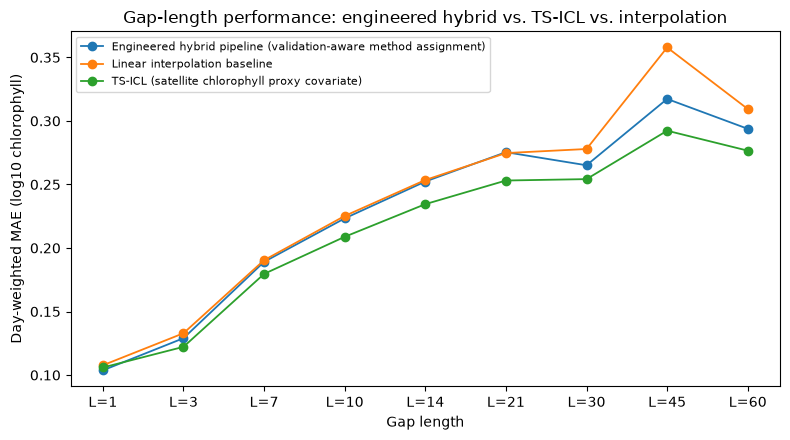

In [6]:
import matplotlib.pyplot as plt

length_order = sorted(pivot.index, key=lambda s: int(s.split("=")[1]))
fig, ax = plt.subplots(figsize=(8, 4.5))
for method in pivot.columns:
    ax.plot(length_order, pivot.loc[length_order, method], marker="o", lw=1.3, label=method)
ax.set_xlabel("Gap length")
ax.set_ylabel("Day-weighted MAE (log10 chlorophyll)")
ax.set_title("Gap-length performance: engineered hybrid vs. TS-ICL vs. interpolation")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## Part B.8 Takeaways

- A gap-edge residual correction model predicts a correction over linear
  interpolation, using both gap edges, pre/post summaries, and engineered
  external predictors.
- It is retrospective by construction (it needs a post-gap observation),
  so it is only usable for artificial-gap validation or after-the-fact
  reconstruction of real gaps -- never for live forecasting.
- It tends to help most on longer/smoother gaps and tends to fail on
  hidden events, the same limitation that affects every method in this
  benchmark.
- As a classical machine-learning comparator to the zero-shot TS-ICL
  foundation model, it avoids depending on a foundation model, and its
  fitting/leakage-control code (`gap_edge_models.py`,
  `probabilistic_models.py`, `engineered_hybrid.py`) is public -- but the
  pooled validation-grade evidence in this benchmark currently favors
  TS-ICL with a satellite chlorophyll proxy covariate. See
  `docs/evidence_and_limitations.md` before drawing a stronger conclusion.